In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

In [25]:
raw_data_url= 'https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv'

df = pd.read_csv(raw_data_url)
df['gdp_per_capita'] = df.apply(lambda row: row['gdp'] / row['population'] if row['population'] != 0 else 0, axis=1)

In [26]:
column_names = df.columns.tolist()
display(column_names)

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'biofuel_cons_change_pct',
 'biofuel_cons_change_twh',
 'biofuel_cons_per_capita',
 'biofuel_consumption',
 'biofuel_elec_per_capita',
 'biofuel_electricity',
 'biofuel_share_elec',
 'biofuel_share_energy',
 'carbon_intensity_elec',
 'coal_cons_change_pct',
 'coal_cons_change_twh',
 'coal_cons_per_capita',
 'coal_consumption',
 'coal_elec_per_capita',
 'coal_electricity',
 'coal_prod_change_pct',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'coal_share_elec',
 'coal_share_energy',
 'electricity_demand',
 'electricity_demand_per_capita',
 'electricity_generation',
 'electricity_share_energy',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'energy_per_capita',
 'energy_per_gdp',
 'fossil_cons_change_pct',
 'fossil_cons_change_twh',
 'fossil_elec_per_capita',
 'fossil_electricity',
 'fossil_energy_per_capita',
 'fossil_fuel_consumption',
 'fossil_share_elec',
 'fossil_share_energy',
 'gas_cons_chan

In [27]:
df.describe()


,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy,gdp_per_capita
count,21812.000000,1.844700e+04,1.177500e+04,1806.000000,2796.000000,2400.000000,2876.000000,5570.000000,5834.000000,5811.000000,...,4127.000000,2508.000000,4740.000000,4845.000000,7278.000000,8234.000000,4153.000000,7197.000000,4193.000000,11775.000000
mean,1974.195718,1.054051e+08,4.260596e+11,45.489759,2.867027,136.600523,39.082519,66.750870,11.262839,1.865575,...,0.258574,306.388427,7.886606,60.060250,67.711201,18.936078,254.848409,1.491997,0.717834,10267.980776
std,35.342860,4.665375e+08,3.508591e+12,266.131064,10.692769,261.757657,116.307666,197.542142,49.585627,5.372183,...,0.773014,6297.500646,39.805408,306.013269,267.759489,110.680131,791.447343,4.688010,2.018520,12957.304957
min,1900.000000,1.833000e+03,1.642060e+08,-100.000000,-49.355000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-100.000000,-50.829000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,365.696439
25%,1946.000000,1.714291e+06,1.438637e+10,-0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,3.921750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2119.789729
50%,1984.000000,6.998022e+06,4.393385e+10,8.189000,0.000000,14.642500,0.694500,0.491000,0.010000,0.096000,...,0.000000,19.564500,0.000000,0.008000,0.000000,0.000000,0.084000,0.000000,0.004000,5572.202993
75%,2004.000000,2.571993e+07,1.830838e+11,26.550000,0.832000,175.006500,12.811500,38.162750,0.720000,1.526500,...,0.026000,46.448500,0.359250,2.782000,3.080750,0.150000,56.324000,0.419000,0.320000,12700.159200
max,2023.000000,8.045311e+09,1.301126e+14,5659.328000,144.146000,2588.512000,1317.625000,2453.043000,678.740000,77.586000,...,9.368000,242384.844000,677.824000,6040.359000,3283.758000,2304.440000,8523.436000,57.716000,25.767000,164146.398304


In [28]:
unique_country = df['country'].unique()
print(unique_country)

['ASEAN (Ember)' 'Afghanistan' 'Africa' 'Africa (EI)' 'Africa (EIA)'
 'Africa (Ember)' 'Africa (Shift)' 'Albania' 'Algeria' 'American Samoa'
 'Angola' 'Antarctica' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Asia & Oceania (EIA)' 'Asia (Ember)' 'Asia Pacific (EI)'
 'Asia and Oceania (Shift)' 'Australia' 'Australia and New Zealand (EIA)'
 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'CIS (EI)' 'Cambodia'
 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central & South America (EIA)' 'Central African Republic'
 'Central America (EI)' 'Central and South America (Shift)' 'Chad' 'Chile'
 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Czechoslovakia' 'Democratic Republic of Congo' 'Denma

In [29]:
# prompt: i want to display the percentage of null values in each column also i want to display no of null values for each country and also in each year the resultant value of null values should be the percentage of null values

# Calculate the percentage of null values in each column
null_percentage = df.isnull().sum() * 100 / len(df)
display("Percentage of null values in each column", null_percentage)




'Percentage of null values in each column'

,0
country,0.000000
year,0.000000
iso_code,22.923162
population,15.427288
gdp,46.015955
...,...
wind_electricity,62.250138
wind_energy_per_capita,80.960022
wind_share_elec,67.004401
wind_share_energy,80.776637


In [30]:
# Calculate the number of null values for each country
null_values_by_country = df.groupby('country').apply(lambda x: x.isnull().sum())
display("\nNumber of null values for each country", null_values_by_country)


<ipython-input-30-5f45fb730290>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_values_by_country = df.groupby('country').apply(lambda x: x.isnull().sum())


'\nNumber of null values for each country'

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy,gdp_per_capita
country,,,,,,,,,,,,,,,,,,,,,
ASEAN (Ember),0,0,24,24,24,24,24,24,24,24,...,24,24,24,24,24,0,24,0,24,24
Afghanistan,0,0,0,0,50,123,123,123,123,100,...,123,123,123,123,100,100,123,100,123,50
Africa,0,0,124,0,124,104,91,90,90,101,...,71,94,66,65,66,66,65,86,65,124
Africa (EI),0,0,59,59,59,39,26,59,25,59,...,6,29,1,0,59,0,59,20,0,59
Africa (EIA),0,0,42,42,42,42,42,42,42,42,...,42,42,42,42,42,42,42,42,42,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
World,0,0,124,0,106,66,66,65,65,100,...,65,79,66,65,65,65,65,85,65,106
Yemen,0,0,0,0,1,44,44,44,44,21,...,44,44,44,44,21,21,44,21,44,1
Yugoslavia,0,0,92,23,24,92,92,92,92,92,...,92,92,92,92,92,92,92,92,92,24


In [52]:
# prompt: i want to divide test data and train data in terms of years. i want train data till 2015 and test data from 2016 to 2019  and delete data from 2020 till now

# Assuming your dataframe 'df' has a 'year' column
train_data = df[df['year'] <= 2015]
test_data = df[(df['year'] >= 2016) & (df['year'] <= 2019)]
df = df[df['year'] <=2019]

print("Shape of training data:", train_data.shape)
print("Shape of testing data:", test_data.shape)
print("Shape of df:", df.shape)


Shape of training data: (15166, 358)
Shape of testing data: (880, 358)
Shape of df: (16046, 358)


In [53]:
train_null_percentage = train_data.isnull().sum() * 100 / len(train_data)
display("Percentage of null values in each column in train data", train_null_percentage)

'Percentage of null values in each column in train data'

,0
country,0.000000
year,0.000000
iso_code,0.000000
population,0.778056
gdp,31.432151
...,...
country_Vietnam,0.000000
country_Western Sahara,0.000000
country_Yemen,0.000000
country_Zambia,0.000000


In [54]:
test_null_percentage = test_data.isnull().sum() * 100 / len(test_data)
display("Percentage of null values in each column in test data", test_null_percentage)

'Percentage of null values in each column in test data'

,0
country,0.000000
year,0.000000
iso_code,0.000000
population,0.909091
gdp,25.000000
...,...
country_Vietnam,0.000000
country_Western Sahara,0.000000
country_Yemen,0.000000
country_Zambia,0.000000


In [56]:
# prompt: convert null in train data to zero

# Fill null values with 0 in the training data
train_data = train_data.fillna(0)
test_data = test_data.fillna(0)


In [57]:
# prompt: get the correalation excluing country name and isocode

import numpy as np
# Remove non-numeric columns for correlation calculation
numeric_df = train_data.select_dtypes(include=np.number)
numeric_df = numeric_df.drop(columns=['year']) # Assuming 'year' is not relevant for correlation

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
display(correlation_matrix)


,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,...,wind_share_elec,wind_share_energy,gdp_per_capita,total_fossil_consumption,total_renewable_consumption,total_energy_consumption,fossil_ratio,renewable_ratio,energy_consumption_lag1,electricity_generation_lag1
population,1.000000,0.557713,0.012514,0.108736,0.068706,0.141518,-0.003700,0.260600,-0.002764,0.083881,...,0.013322,0.030747,0.020124,0.513792,0.384422,0.422665,0.145364,0.052795,0.382768,0.407023
gdp,0.557713,1.000000,0.035195,0.441477,0.328642,0.549481,0.092718,0.699686,0.031809,0.199080,...,0.077302,0.117767,0.310183,0.933809,0.700288,0.852047,0.320914,0.136615,0.798430,0.846241
biofuel_cons_change_pct,0.012514,0.035195,1.000000,0.044820,0.057340,0.010152,0.137794,0.052816,0.038051,0.036907,...,0.025124,0.037332,0.091642,0.024131,0.028404,0.034439,0.143869,0.073240,0.032877,0.030888
biofuel_cons_change_twh,0.108736,0.441477,0.044820,1.000000,0.429699,0.670339,0.077233,0.544906,0.034124,0.360293,...,0.041867,0.061696,0.122829,0.350065,0.379252,0.437240,0.147416,0.109577,0.427507,0.407604
biofuel_cons_per_capita,0.068706,0.328642,0.057340,0.429699,1.000000,0.636324,0.382814,0.539776,0.161644,0.747248,...,0.296485,0.393388,0.321305,0.221043,0.448733,0.300663,0.362674,0.408989,0.292504,0.290429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
total_energy_consumption,0.422665,0.852047,0.034439,0.437240,0.300663,0.525706,0.089988,0.692024,0.031934,0.157201,...,0.068029,0.098907,0.202596,0.799670,0.819642,1.000000,0.358877,0.147521,0.931166,0.857966
fossil_ratio,0.145364,0.320914,0.143869,0.147416,0.362674,0.183350,0.310470,0.347285,0.126497,0.268239,...,0.210630,0.287022,0.430268,0.263165,0.327074,0.358877,1.000000,0.452275,0.329441,0.299211
renewable_ratio,0.052795,0.136615,0.073240,0.109577,0.408989,0.215130,0.340970,0.238027,0.108583,0.410032,...,0.166324,0.256398,0.375272,0.082985,0.438381,0.147521,0.452275,1.000000,0.135842,0.135751
energy_consumption_lag1,0.382768,0.798430,0.032877,0.427507,0.292504,0.511366,0.086919,0.668821,0.030213,0.150476,...,0.065886,0.095990,0.188258,0.744044,0.765632,0.931166,0.329441,0.135842,1.000000,0.925121


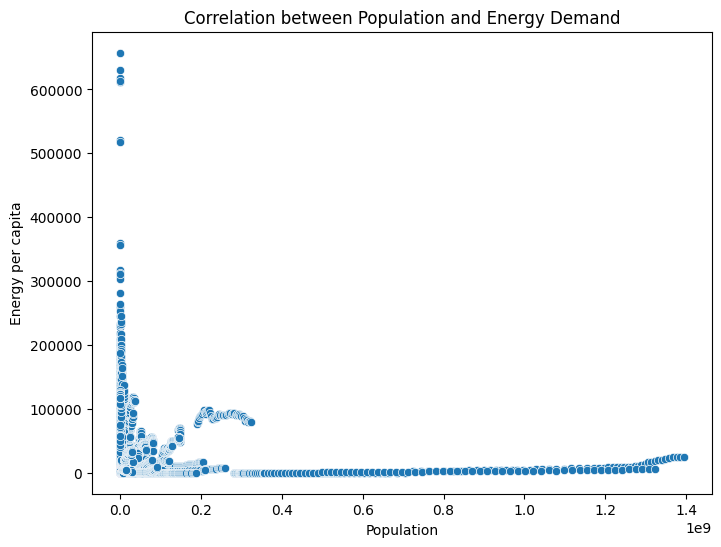

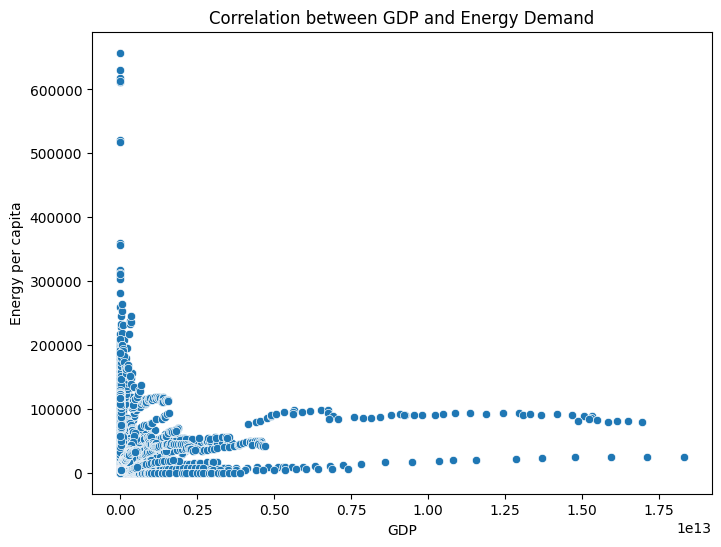

Correlation between population and energy demand: -0.019722443268404284
Correlation between GDP and energy demand: 0.17300428815951588


In [58]:
# prompt: find correlation between population and energy demand , gdp vs energy demand, fossil fuel vs carbon emissions

import matplotlib.pyplot as plt
# Plotting correlation between population and energy demand
plt.figure(figsize=(8, 6))
sns.scatterplot(x='population', y='energy_per_capita', data=train_data)
plt.title('Correlation between Population and Energy Demand')
plt.xlabel('Population')
plt.ylabel('Energy per capita')
plt.show()

# Plotting correlation between GDP and energy demand
plt.figure(figsize=(8, 6))
sns.scatterplot(x='gdp', y='energy_per_capita', data=train_data)
plt.title('Correlation between GDP and Energy Demand')
plt.xlabel('GDP')
plt.ylabel('Energy per capita')
plt.show()




#Specific correlation values
population_energy_correlation = train_data['population'].corr(train_data['energy_per_capita'])
print(f"Correlation between population and energy demand: {population_energy_correlation}")

gdp_energy_correlation = train_data['gdp'].corr(train_data['energy_per_capita'])
print(f"Correlation between GDP and energy demand: {gdp_energy_correlation}")




In [59]:


df = df.dropna(subset=['iso_code'])


In [60]:
df['total_fossil_consumption'] = df['coal_consumption'] + df['oil_consumption'] + df['gas_consumption']
df['total_renewable_consumption'] = df['solar_consumption'] + df['wind_consumption'] + df['hydro_consumption'] + df['biofuel_consumption']
df['total_energy_consumption'] = df['total_fossil_consumption'] + df['total_renewable_consumption']
df['fossil_ratio'] = df['total_fossil_consumption'] / df['total_energy_consumption']
df['renewable_ratio'] = df['total_renewable_consumption'] / df['total_energy_consumption']

In [61]:
df['energy_consumption_lag1'] = df['total_energy_consumption'].shift(1)
df['electricity_generation_lag1'] = df['electricity_generation'].shift(1)

In [62]:
# prompt: use categorical encoding to encode country

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'country' column
df['country_encoded'] = label_encoder.fit_transform(df['country'])




In [63]:
# prompt: do one hot encoding for country and drop the country_encoded column


country_encoded = pd.get_dummies(df['country'], prefix='country')

# Concatenate the one-hot encoded columns with the original DataFrame
df = pd.concat([df, country_encoded], axis=1)

# Drop the original 'country' and 'country_encoded' columns
df = df.drop([ 'country_encoded'], axis=1)


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [65]:
features = ['total_fossil_consumption', 'total_renewable_consumption', 'fossil_ratio',
            'renewable_ratio', 'energy_consumption_lag1', 'electricity_generation_lag1'] + list(country_encoded.columns)
target_energy = 'total_energy_consumption'
target_generation = 'electricity_generation'


In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_errors(y_actual, y_pred):
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)
    return mae, mse, rmse, r2

In [89]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def train_country_lstm_model(country_name, train_data, test_data, features, target_energy, target_generation):
    """
    Train an LSTM model for energy consumption and electricity generation for each country.

    Parameters:
    - country_name: Name of the country to train model
    - train_data: Training data
    - test_data: Testing data
    - features: List of features to use for training
    - target_energy: Target variable for energy consumption
    - target_generation: Target variable for electricity generation

    Returns:
    - Errors for LSTM model for both energy consumption and electricity generation
    """
    # Filter data for the current country
    country_train_data = train_data[train_data['country'] == country_name]
    country_test_data = test_data[test_data['country'] == country_name]

    # Separate features and targets for training and testing sets
    X_train_energy = country_train_data[features]
    y_train_energy = country_train_data[target_energy]
    X_test_energy = country_test_data[features]
    y_test_energy = country_test_data[target_energy]

    X_train_generation = country_train_data[features]
    y_train_generation = country_train_data[target_generation]
    X_test_generation = country_test_data[features]
    y_test_generation = country_test_data[target_generation]

    # Scale the data using MinMaxScaler
    scaler_energy = MinMaxScaler()
    X_train_energy_scaled = scaler_energy.fit_transform(X_train_energy)
    X_test_energy_scaled = scaler_energy.transform(X_test_energy)
    y_train_energy_scaled = scaler_energy.fit_transform(y_train_energy.values.reshape(-1, 1))
    y_test_energy_scaled = scaler_energy.transform(y_test_energy.values.reshape(-1, 1))

    scaler_generation = MinMaxScaler()
    X_train_generation_scaled = scaler_generation.fit_transform(X_train_generation)
    X_test_generation_scaled = scaler_generation.transform(X_test_generation)
    y_train_generation_scaled = scaler_generation.fit_transform(y_train_generation.values.reshape(-1, 1))
    y_test_generation_scaled = scaler_generation.transform(y_test_generation.values.reshape(-1, 1))

    # Reshape data for LSTM input (samples, timesteps, features)
    X_train_energy_reshaped = X_train_energy_scaled.reshape(X_train_energy_scaled.shape[0], 1, X_train_energy_scaled.shape[1])
    X_test_energy_reshaped = X_test_energy_scaled.reshape(X_test_energy_scaled.shape[0], 1, X_test_energy_scaled.shape[1])
    X_train_generation_reshaped = X_train_generation_scaled.reshape(X_train_generation_scaled.shape[0], 1, X_train_generation_scaled.shape[1])
    X_test_generation_reshaped = X_test_generation_scaled.reshape(X_test_generation_scaled.shape[0], 1, X_test_generation_scaled.shape[1])

    # Define and train the LSTM model for energy consumption
    model_energy = Sequential()
    model_energy.add(LSTM(50, activation='relu', input_shape=(X_train_energy_reshaped.shape[1], X_train_energy_reshaped.shape[2])))
    model_energy.add(Dense(1))
    model_energy.compile(optimizer='adam', loss='mse')
    model_energy.fit(X_train_energy_reshaped, y_train_energy_scaled, epochs=50, batch_size=32, verbose=0)

    # Define and train the LSTM model for electricity generation
    model_generation = Sequential()
    model_generation.add(LSTM(50, activation='relu', input_shape=(X_train_generation_reshaped.shape[1], X_train_generation_reshaped.shape[2])))
    model_generation.add(Dense(1))
    model_generation.compile(optimizer='adam', loss='mse')
    model_generation.fit(X_train_generation_reshaped, y_train_generation_scaled, epochs=50, batch_size=32, verbose=0)

    # Make predictions
    y_pred_energy = model_energy.predict(X_test_energy_reshaped)
    y_pred_generation = model_generation.predict(X_test_generation_reshaped)

    # Inverse transform the predictions to the original scale
    y_pred_energy = scaler_energy.inverse_transform(y_pred_energy)
    y_pred_generation = scaler_generation.inverse_transform(y_pred_generation)

    # Calculate errors for LSTM
    mae_energy, mse_energy, rmse_energy, r2_energy = calculate_errors(y_test_energy, y_pred_energy)
    mae_generation, mse_generation, rmse_generation, r2_generation = calculate_errors(y_test_generation, y_pred_generation)

    return mae_energy, mse_energy, rmse_energy, r2_energy, mae_generation, mse_generation, rmse_generation, r2_generation


In [90]:
from statsmodels.tsa.arima.model import ARIMA

def train_country_arima_model(country_name, train_data, test_data, target_energy, target_generation):
    """
    Train an ARIMA model for energy consumption and electricity generation for each country.

    Parameters:
    - country_name: Name of the country to train model
    - train_data: Training data
    - test_data: Testing data
    - target_energy: Target variable for energy consumption
    - target_generation: Target variable for electricity generation

    Returns:
    - Errors for ARIMA model for both energy consumption and electricity generation
    """
    # Filter data for the current country
    country_train_data = train_data[train_data['country'] == country_name]
    country_test_data = test_data[test_data['country'] == country_name]

    # Extract time series data for energy consumption and electricity generation
    energy_consumption = country_train_data[target_energy]
    electricity_generation = country_train_data[target_generation]

    # Train the ARIMA model for energy consumption
    model_energy = ARIMA(energy_consumption, order=(5, 1, 0))
    model_energy_fit = model_energy.fit()

    # Train the ARIMA model for electricity generation
    model_generation = ARIMA(electricity_generation, order=(5, 1, 0))
    model_generation_fit = model_generation.fit()

    # Make predictions
    forecast_energy = model_energy_fit.forecast(steps=len(country_test_data))
    forecast_generation = model_generation_fit.forecast(steps=len(country_test_data))

    # Calculate errors for ARIMA
    mae_energy, mse_energy, rmse_energy, r2_energy = calculate_errors(country_test_data[target_energy], forecast_energy)
    mae_generation, mse_generation, rmse_generation, r2_generation = calculate_errors(country_test_data[target_generation], forecast_generation)

    return mae_energy, mse_energy, rmse_energy, r2_energy, mae_generation, mse_generation, rmse_generation, r2_generation


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


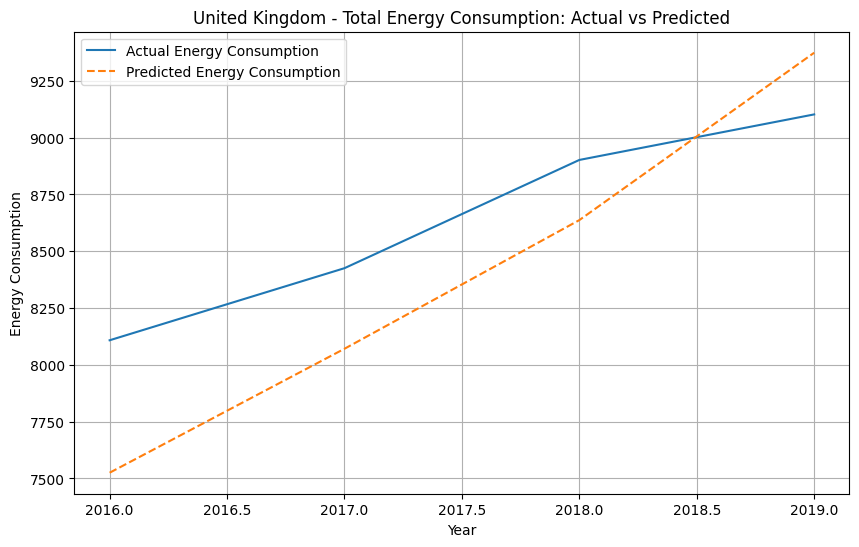

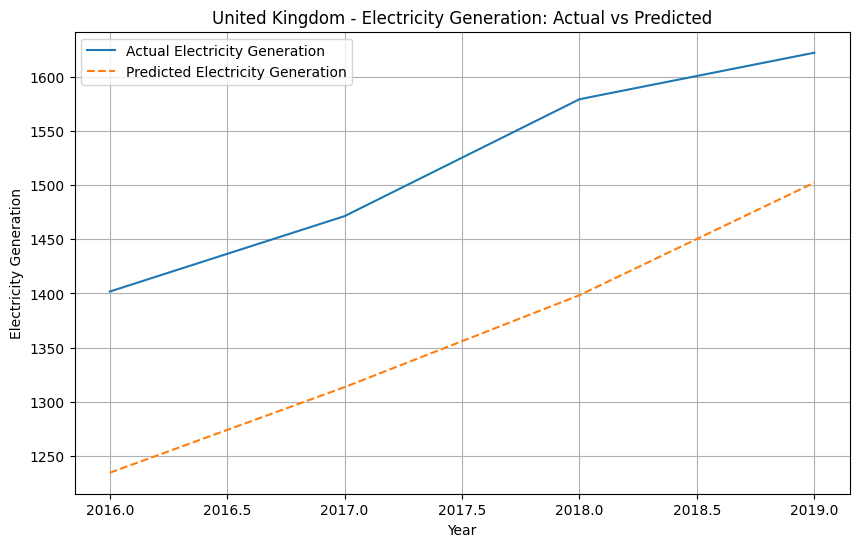

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


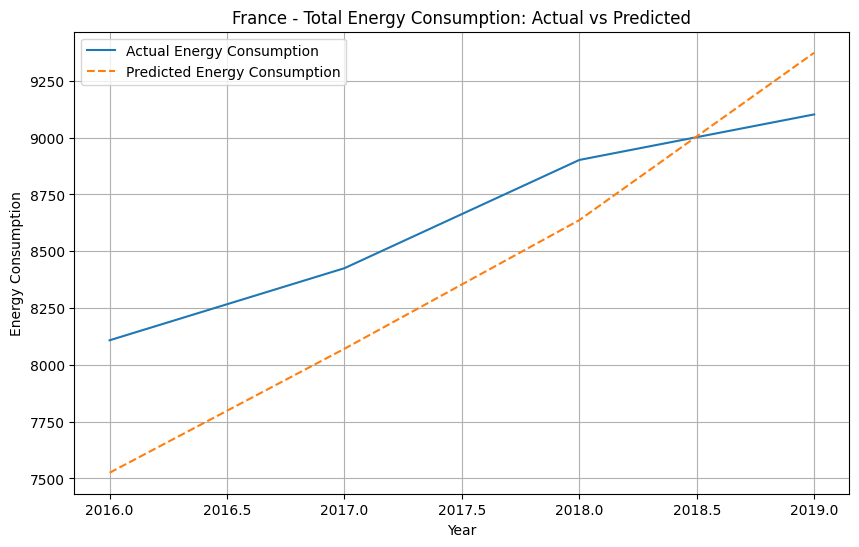

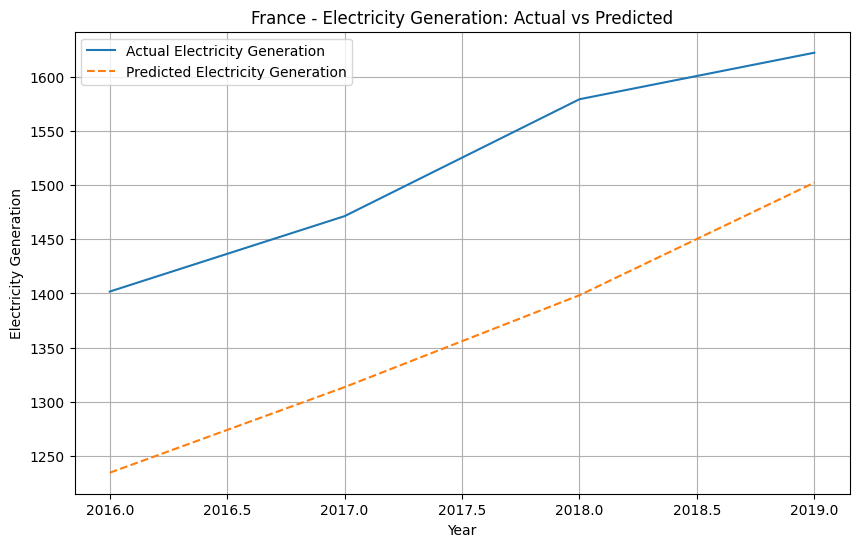

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


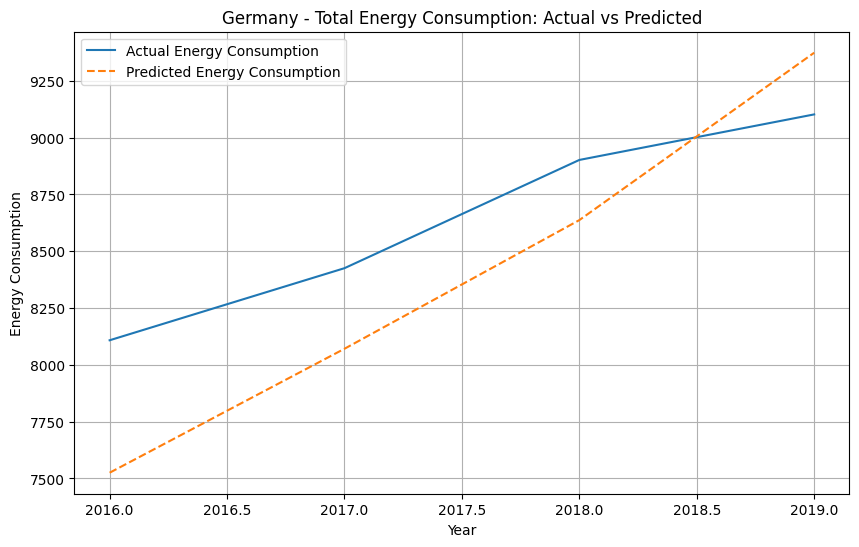

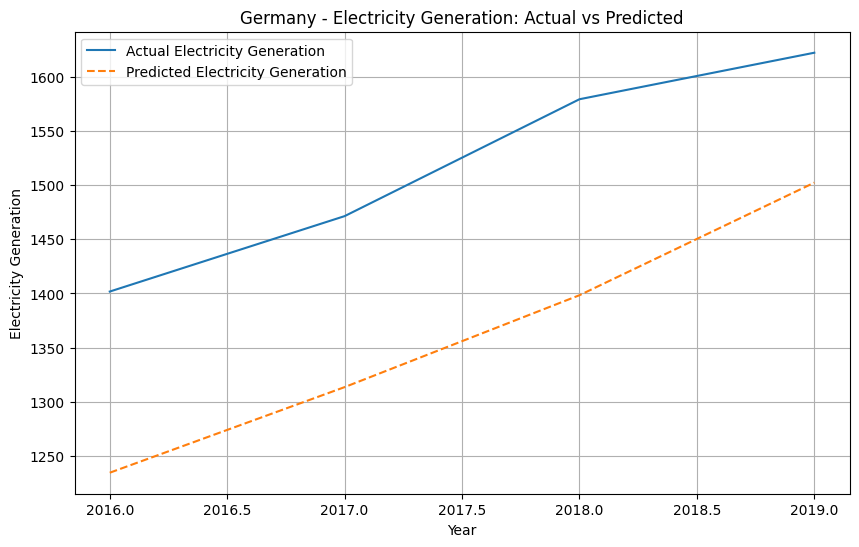

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


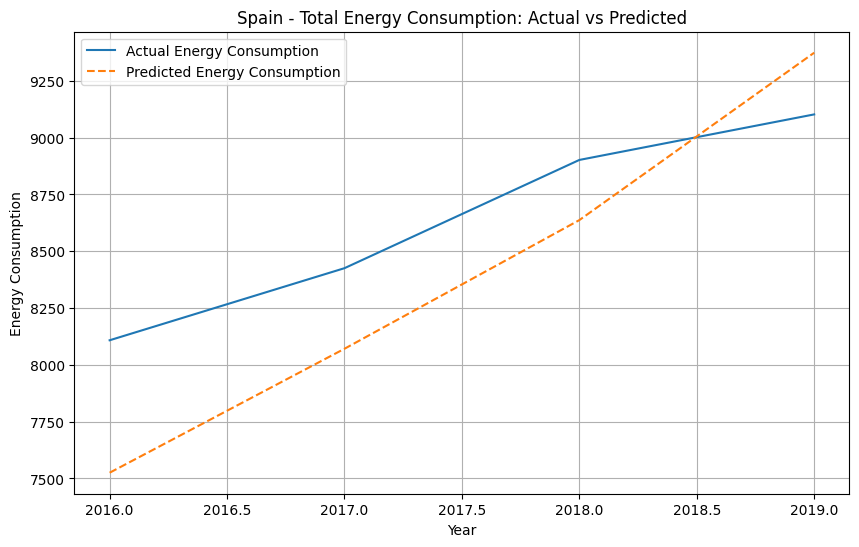

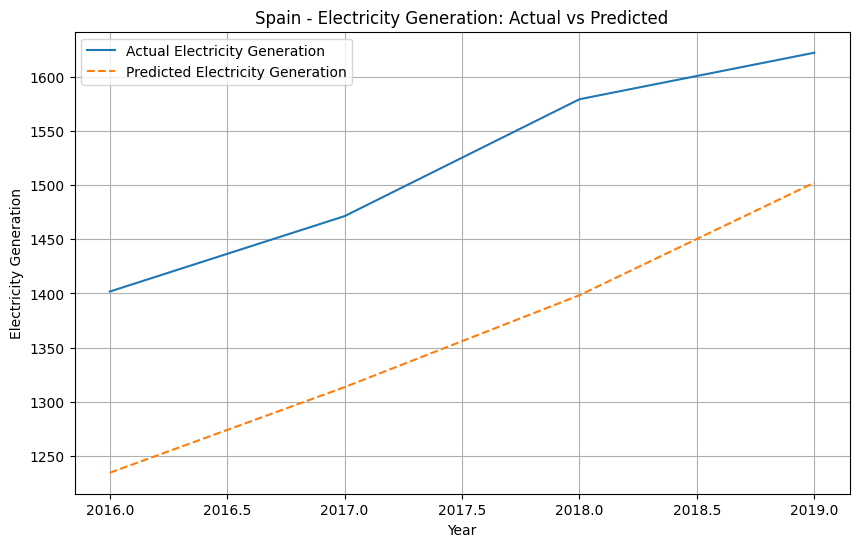

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


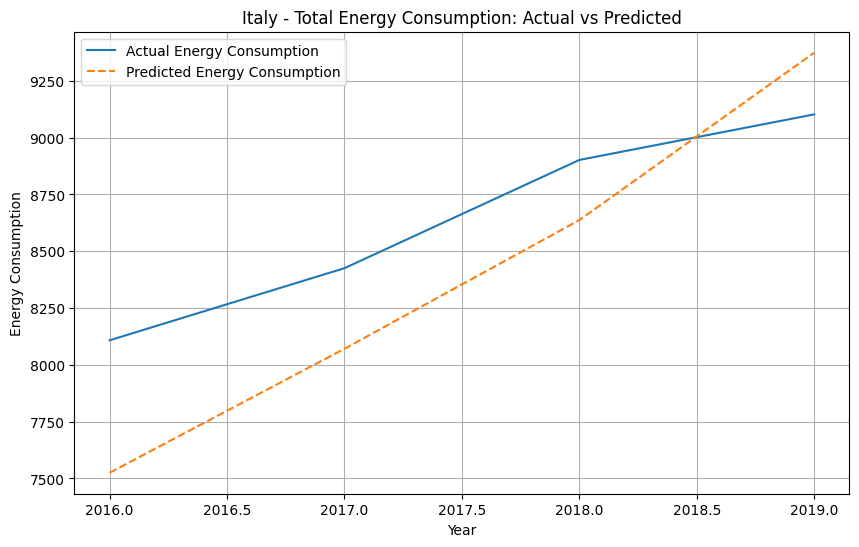

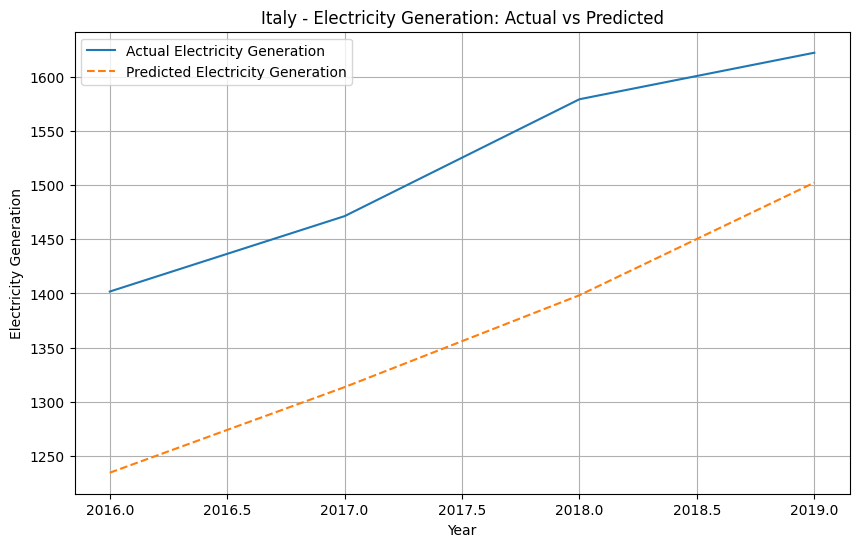

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


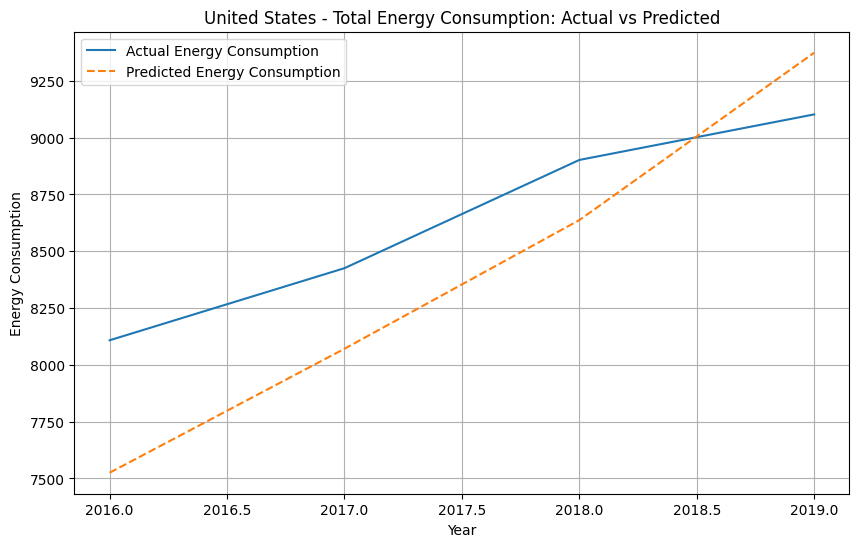

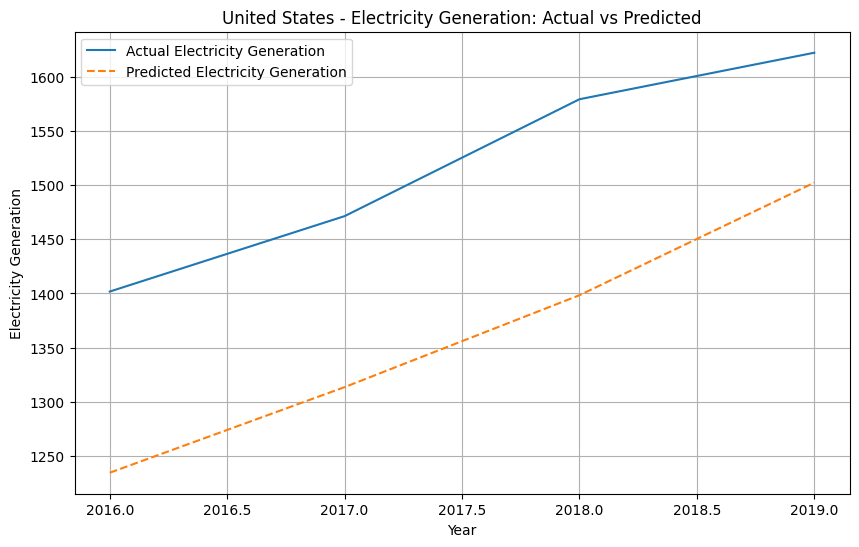

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


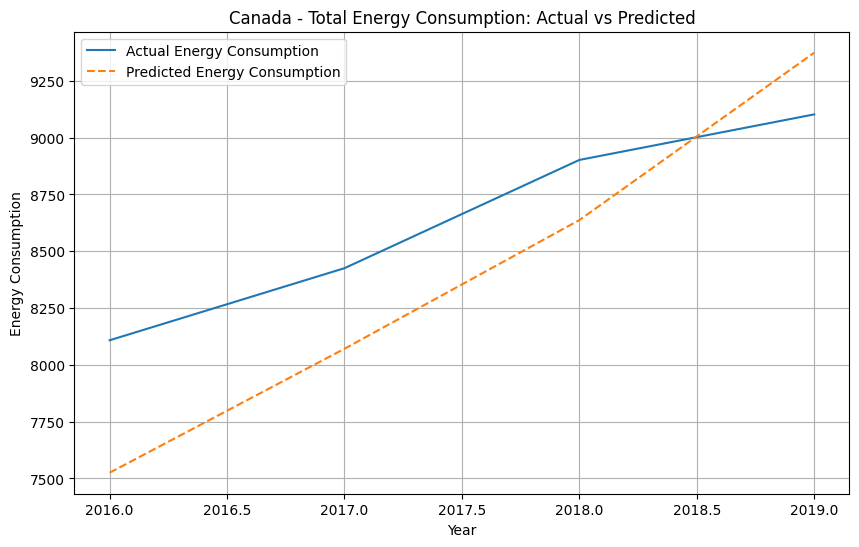

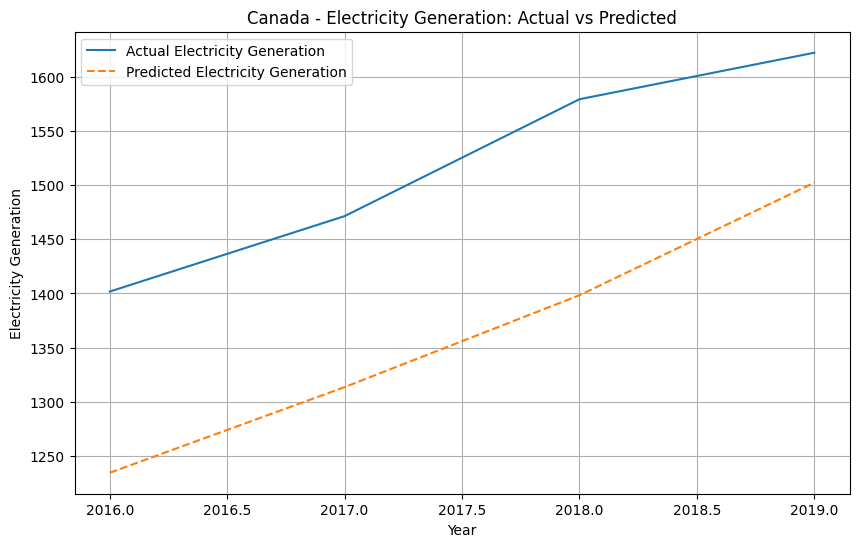

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


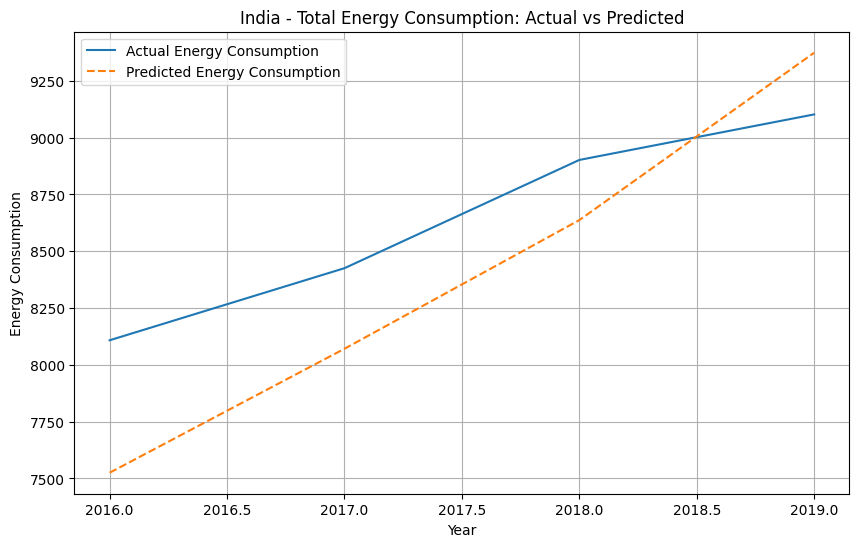

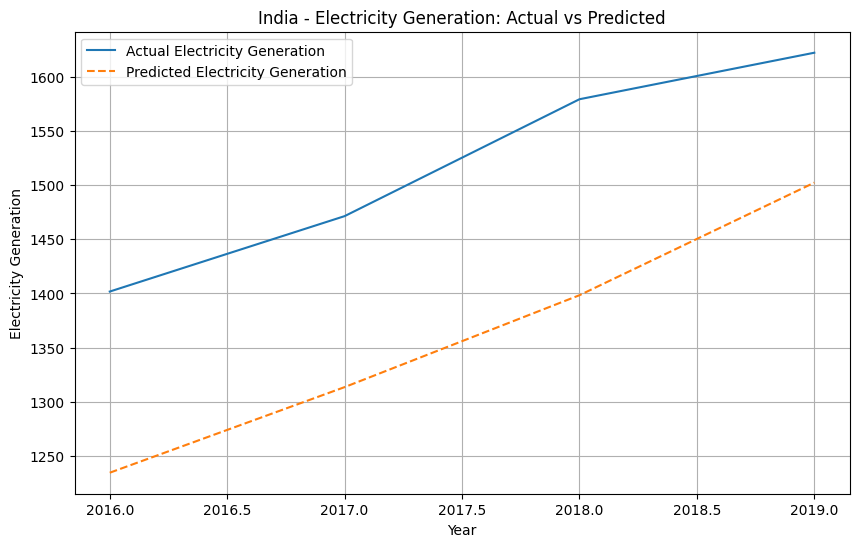

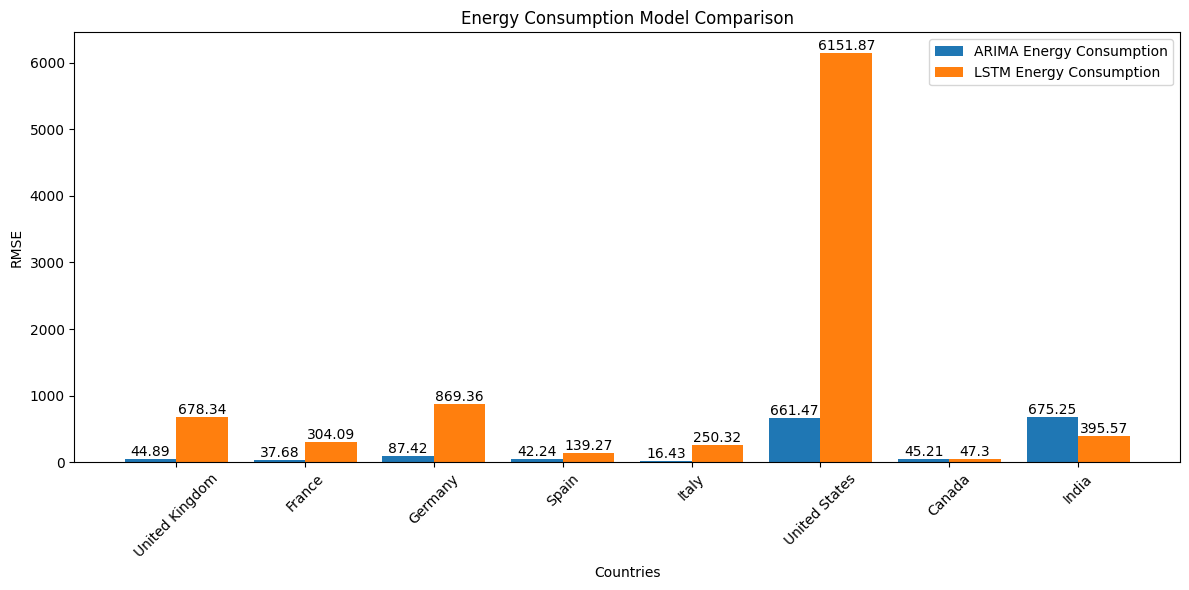

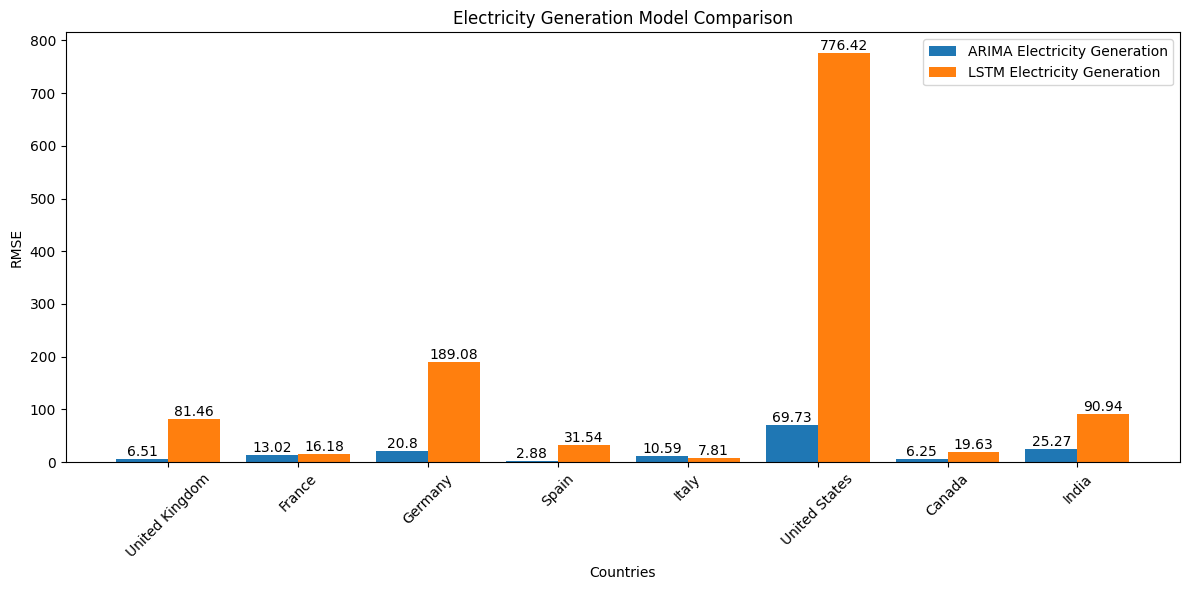

In [96]:
import matplotlib.pyplot as plt

def compare_model_errors(countries, train_data, test_data, features, target_energy, target_generation):
    # Arrays to store errors for comparison
    lstm_errors_energy, lstm_errors_generation = [], []
    arima_errors_energy, arima_errors_generation = [], []

    # Iterate through each country to train both models and calculate errors
    for country in countries:
        # Train ARIMA model and get errors
        mae_energy_arima, mse_energy_arima, rmse_energy_arima, r2_energy_arima, mae_generation_arima, mse_generation_arima, rmse_generation_arima, r2_generation_arima = train_country_arima_model(
            country, train_data, test_data, target_energy, target_generation)

        # Train LSTM model and get errors
        mae_energy_lstm, mse_energy_lstm, rmse_energy_lstm, r2_energy_lstm, mae_generation_lstm, mse_generation_lstm, rmse_generation_lstm, r2_generation_lstm = train_country_lstm_model(
            country, train_data, test_data, features, target_energy, target_generation)

        # Append errors to respective lists
        lstm_errors_energy.append(rmse_energy_lstm)
        lstm_errors_generation.append(rmse_generation_lstm)
        arima_errors_energy.append(rmse_energy_arima)
        arima_errors_generation.append(rmse_generation_arima)

        plt.figure(figsize=(10, 6))
        plt.plot(country_test_data['year'], y_test_energy, label='Actual Energy Consumption')
        plt.plot(country_test_data['year'], y_pred_energy, label='Predicted Energy Consumption', linestyle='--')
        plt.title(f'{country} - Total Energy Consumption: Actual vs Predicted')
        plt.xlabel('Year')
        plt.ylabel('Energy Consumption')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.plot(country_test_data['year'], y_test_generation, label='Actual Electricity Generation')
        plt.plot(country_test_data['year'], y_pred_generation, label='Predicted Electricity Generation', linestyle='--')
        plt.title(f'{country} - Electricity Generation: Actual vs Predicted')
        plt.xlabel('Year')
        plt.ylabel('Electricity Generation')
        plt.legend()
        plt.grid(True)
        plt.show()

    # Plot errors for comparison
    plt.figure(figsize=(12, 6))
    x = np.arange(len(countries))
    bar_width = 0.4

    # Plotting ARIMA Energy Consumption
    bars_arima_energy = plt.bar(x - bar_width/2, arima_errors_energy, bar_width, label='ARIMA Energy Consumption')
    # Plotting LSTM Energy Consumption
    bars_lstm_energy = plt.bar(x + bar_width/2, lstm_errors_energy, bar_width, label='LSTM Energy Consumption')

    # Adding values on top of the bars for ARIMA and LSTM
    for bar in bars_arima_energy:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)

    for bar in bars_lstm_energy:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)

    plt.xticks(x, countries)
    plt.xlabel('Countries')
    plt.ylabel('RMSE')
    plt.title('Energy Consumption Model Comparison')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plotting Electricity Generation Comparison
    plt.figure(figsize=(12, 6))
    # Plotting ARIMA Electricity Generation
    bars_arima_generation = plt.bar(x - bar_width/2, arima_errors_generation, bar_width, label='ARIMA Electricity Generation')
    # Plotting LSTM Electricity Generation
    bars_lstm_generation = plt.bar(x + bar_width/2, lstm_errors_generation, bar_width, label='LSTM Electricity Generation')

    # Adding values on top of the bars for ARIMA and LSTM
    for bar in bars_arima_generation:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)

    for bar in bars_lstm_generation:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)

    plt.xticks(x, countries)
    plt.xlabel('Countries')
    plt.ylabel('RMSE')
    plt.title('Electricity Generation Model Comparison')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Example usage
countries = ['United Kingdom', 'France', 'Germany', 'Spain', 'Italy', 'United States', 'Canada', 'India']
compare_model_errors(countries, train_data, test_data, features, target_energy, target_generation)
